
# Prediksi Keberhasilan Penempatan Kerja dan Estimasi Besaran Gaji
Data: performa akademik dan faktor-faktor dari mahasiswa.

Target:
1. Status keberhasilan penempatan kerja (Classification)
2.  Estimasi besaran gaji (Regression)

## EDA

In [1]:
import pandas as pd
import os
import numpy as np
import random
import seaborn as sns
from matplotlib import pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import (RobustScaler, LabelEncoder,
                                   OneHotEncoder, OrdinalEncoder)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# Klasifikasi
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)

# Regresi
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error as mae, mean_squared_error as mse, r2_score as r2

# Hyperopt
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK

import pickle

SEED = 123
random.seed(SEED)
np.random.seed(SEED)

In [2]:
df_features = pd.read_csv('./Dataset/A.csv')
df_target   = pd.read_csv('./Dataset/A_targets.csv')

df_features.head()

,Student_ID,gender,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,...,aptitude_skill_rating,hackathons_participated,certifications_count,sleep_hours,stress_level,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement
0,1,Male,ECE,8.74,74.0,75.0,0,3.8,71.1,7,...,5,4,5,6.5,8,Yes,Medium,Tier 2,Yes,Medium
1,2,Female,ECE,7.80,75.3,69.7,0,6.3,69.5,5,...,3,4,1,7.1,8,Yes,Medium,Tier 3,Yes,Low
2,3,Female,IT,6.95,62.8,68.3,0,1.5,62.5,8,...,4,6,3,6.1,2,No,Low,Tier 2,Yes,High
3,4,Male,ECE,7.46,57.9,51.4,1,4.7,64.6,6,...,4,2,2,7.3,7,No,Medium,Tier 1,Yes,Low
4,5,Male,IT,6.86,61.3,73.5,2,5.2,75.9,3,...,3,2,1,6.0,7,No,Medium,Tier 1,Yes,Medium


In [3]:
df = pd.merge(df_features, df_target, on='Student_ID')
df = df.drop_duplicates(subset=['Student_ID'], keep='first')

df = df.drop(columns=['Student_ID'])

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       5000 non-null   object 
 1   branch                       5000 non-null   object 
 2   cgpa                         5000 non-null   float64
 3   tenth_percentage             5000 non-null   float64
 4   twelfth_percentage           5000 non-null   float64
 5   backlogs                     5000 non-null   int64  
 6   study_hours_per_day          5000 non-null   float64
 7   attendance_percentage        5000 non-null   float64
 8   projects_completed           5000 non-null   int64  
 9   internships_completed        5000 non-null   int64  
 10  coding_skill_rating          5000 non-null   int64  
 11  communication_skill_rating   5000 non-null   int64  
 12  aptitude_skill_rating        5000 non-null   int64  
 13  hackathons_partici

In [5]:
target_cols = ['placement_status', 'salary_lpa']

num_cols = [col for col in df.select_dtypes(include=['int64', 'float64']).columns if col not in target_cols]
cat_cols = [col for col in df.columns if col not in num_cols and col not in target_cols]

print(f'Numeric ({len(num_cols)}) : {num_cols}')
print(f'Categoric ({len(cat_cols)}): {cat_cols}')

Numeric (15) : ['cgpa', 'tenth_percentage', 'twelfth_percentage', 'backlogs', 'study_hours_per_day', 'attendance_percentage', 'projects_completed', 'internships_completed', 'coding_skill_rating', 'communication_skill_rating', 'aptitude_skill_rating', 'hackathons_participated', 'certifications_count', 'sleep_hours', 'stress_level']
Categoric (7): ['gender', 'branch', 'part_time_job', 'family_income_level', 'city_tier', 'internet_access', 'extracurricular_involvement']


### MISSING VALUES

In [6]:
missing = df.isnull().sum()
print(missing[missing > 0])
print(f'Total missing: {df.isnull().sum().sum()}')

extracurricular_involvement    1006
dtype: int64
Total missing: 1006


In [7]:
mode_val = df['extracurricular_involvement'].mode()[0]
df['extracurricular_involvement'] = df['extracurricular_involvement'].fillna(mode_val)

print('Missing setelah imputasi:', df.isnull().sum().sum())

Missing setelah imputasi: 0


saya impute dengan modus karena kolom extracur adalah kolom kategorik ordinal dengan sekitar 20% missing, jadi mending pakai modus daripada melakukan drop baris yang missing

### EDA

In [8]:
df[num_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
cgpa,5000.0,8.28,1.01,5.0,7.61,8.32,9.02,10.0
tenth_percentage,5000.0,74.54,10.27,50.0,67.40,74.70,82.00,100.0
twelfth_percentage,5000.0,74.54,10.24,50.0,67.60,74.80,81.70,100.0
backlogs,5000.0,0.34,0.61,0.0,0.00,0.00,1.00,5.0
study_hours_per_day,5000.0,4.04,1.97,0.0,2.70,4.00,5.40,10.0
attendance_percentage,5000.0,72.04,7.72,44.7,66.60,72.05,77.20,99.2
projects_completed,5000.0,5.53,2.05,0.0,4.00,6.00,7.00,8.0
internships_completed,5000.0,2.13,1.14,0.0,1.00,2.00,3.00,4.0
coding_skill_rating,5000.0,3.73,1.28,1.0,3.00,4.00,5.00,5.0
communication_skill_rating,5000.0,3.03,1.41,1.0,2.00,3.00,4.00,5.0


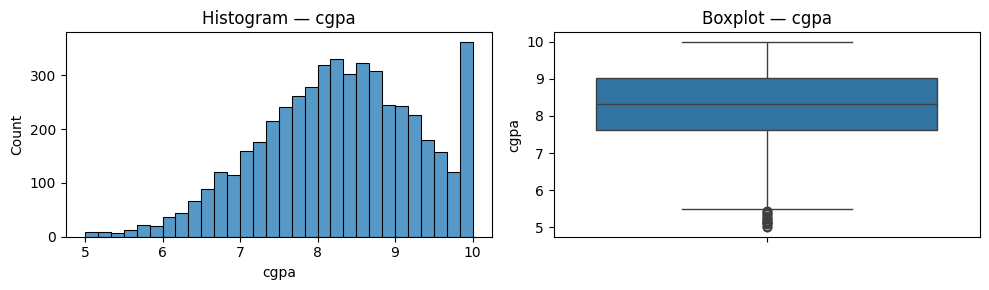

Skewness : -0.2876
Kurtosis : -0.3221
----------------------------------------


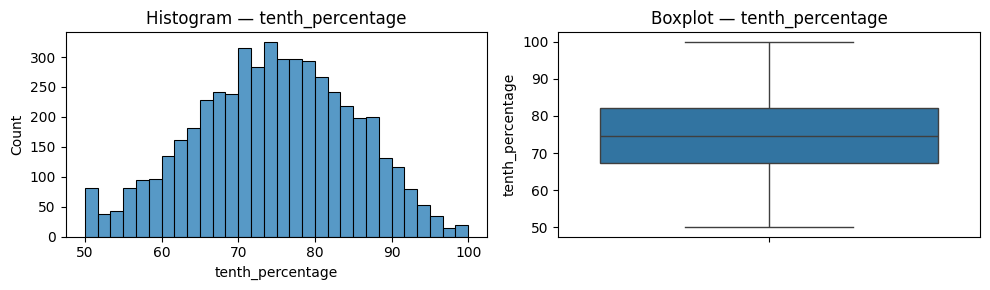

Skewness : -0.1350
Kurtosis : -0.4445
----------------------------------------


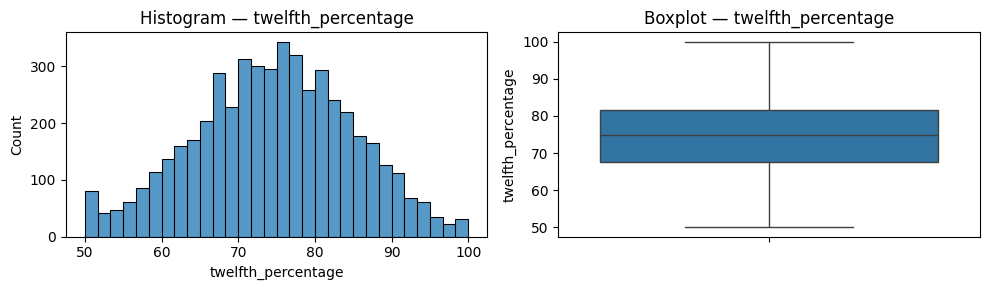

Skewness : -0.0907
Kurtosis : -0.3525
----------------------------------------


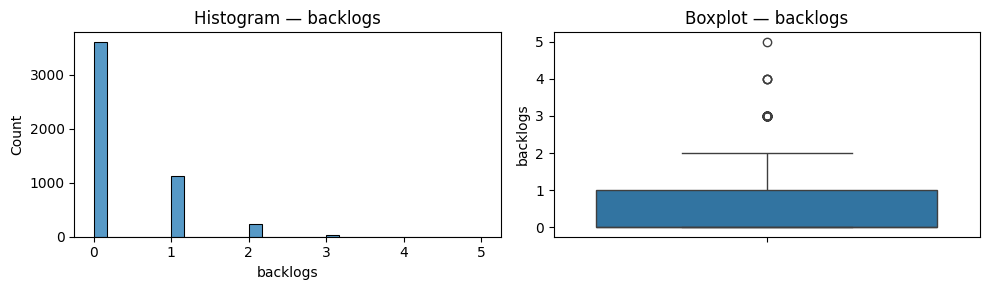

Skewness : 1.9031
Kurtosis : 3.9740
----------------------------------------


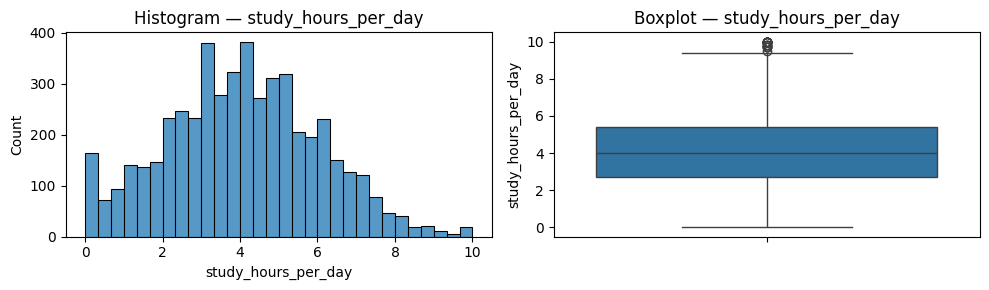

Skewness : 0.1069
Kurtosis : -0.2869
----------------------------------------


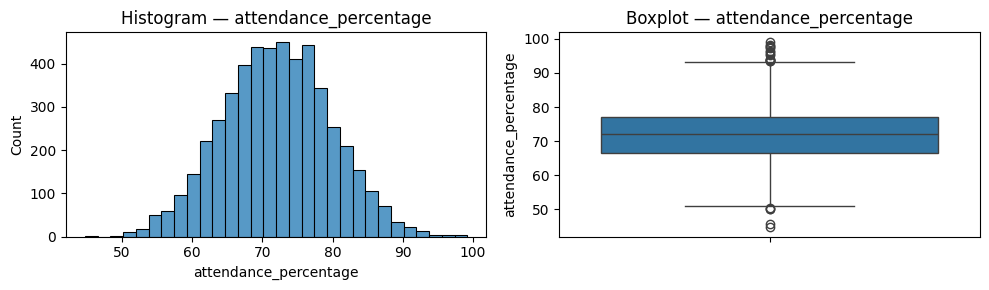

Skewness : 0.0356
Kurtosis : -0.1324
----------------------------------------


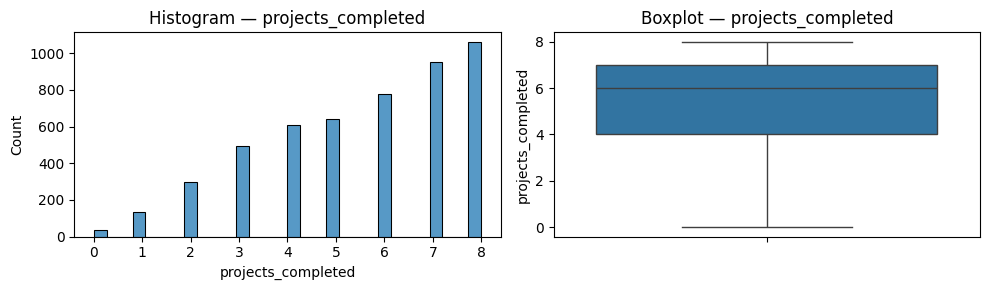

Skewness : -0.5333
Kurtosis : -0.6891
----------------------------------------


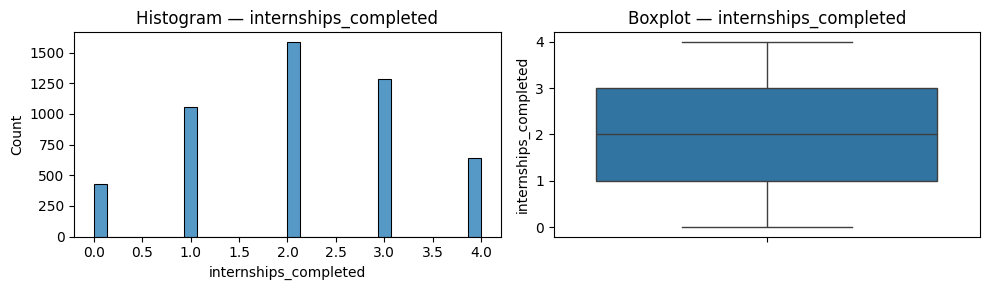

Skewness : -0.0883
Kurtosis : -0.7617
----------------------------------------


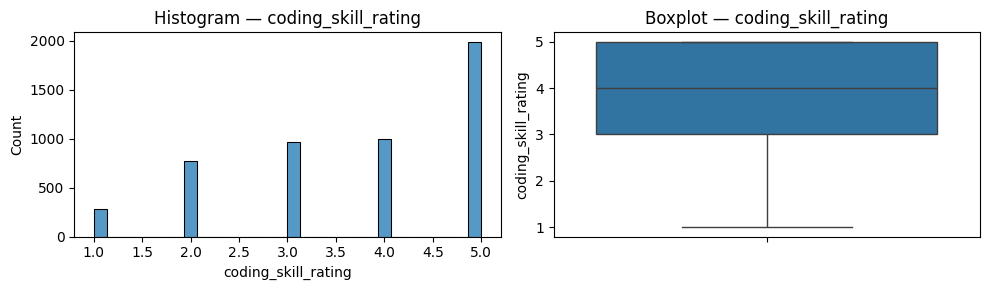

Skewness : -0.5653
Kurtosis : -0.9206
----------------------------------------


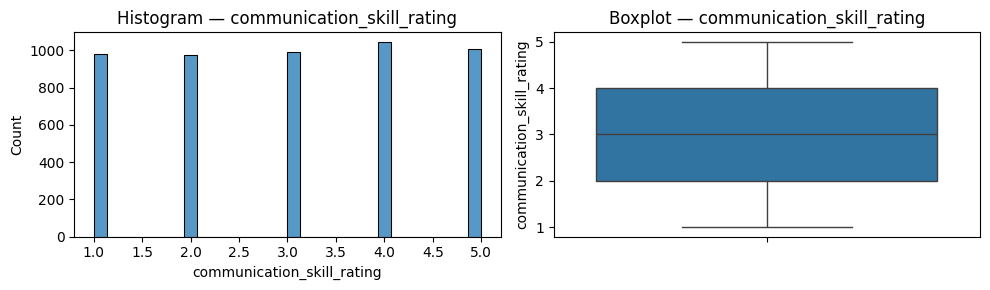

Skewness : -0.0326
Kurtosis : -1.2980
----------------------------------------


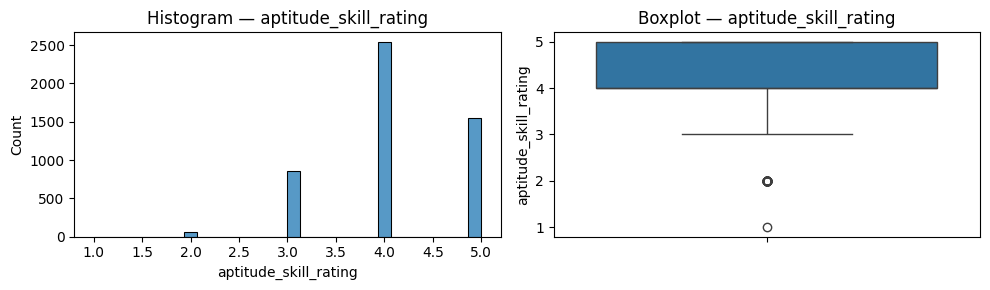

Skewness : -0.3679
Kurtosis : -0.3613
----------------------------------------


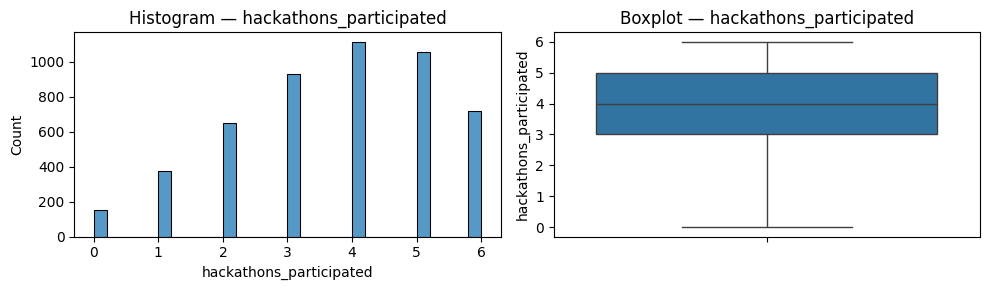

Skewness : -0.3743
Kurtosis : -0.6548
----------------------------------------


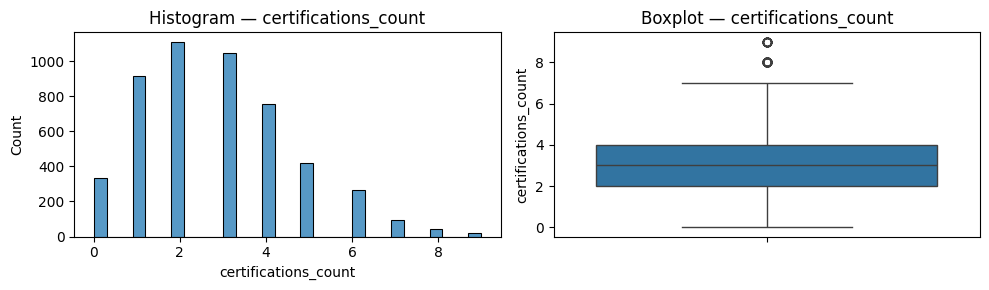

Skewness : 0.6376
Kurtosis : 0.2144
----------------------------------------


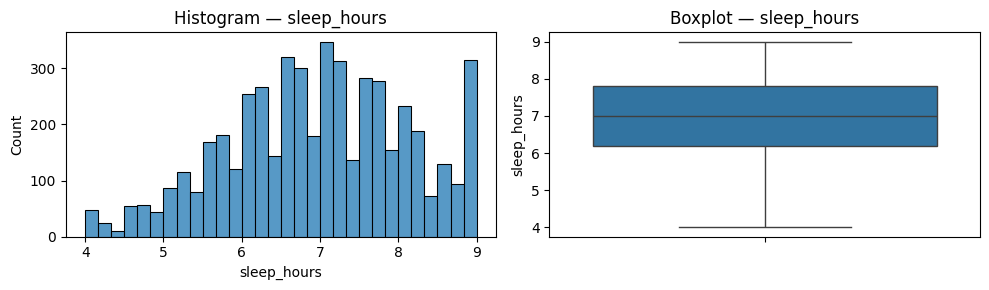

Skewness : -0.1719
Kurtosis : -0.4924
----------------------------------------


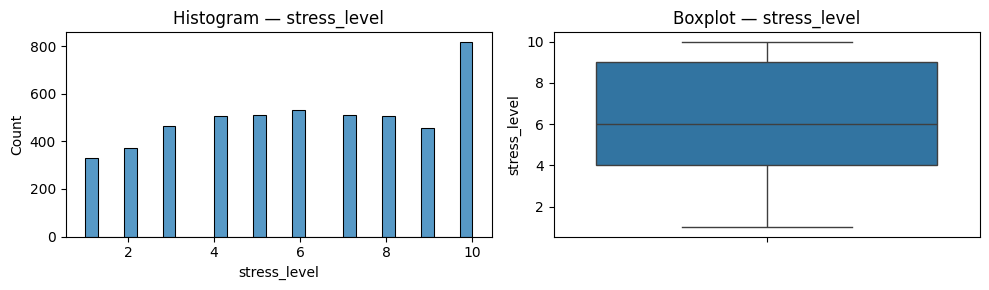

Skewness : -0.1341
Kurtosis : -1.1718
----------------------------------------


In [9]:
def check_distribution_outliers(df, columns):
    for col in columns:
        plt.figure(figsize=(10, 3))

        plt.subplot(1, 2, 1)
        sns.histplot(df[col], bins=30)
        plt.title(f'Histogram — {col}')

        plt.subplot(1, 2, 2)
        sns.boxplot(y=df[col])
        plt.title(f'Boxplot — {col}')

        plt.tight_layout()
        plt.show()

        print(f'Skewness : {df[col].skew():.4f}')
        print(f'Kurtosis : {df[col].kurt():.4f}')
        print('-' * 40)

check_distribution_outliers(df, num_cols)

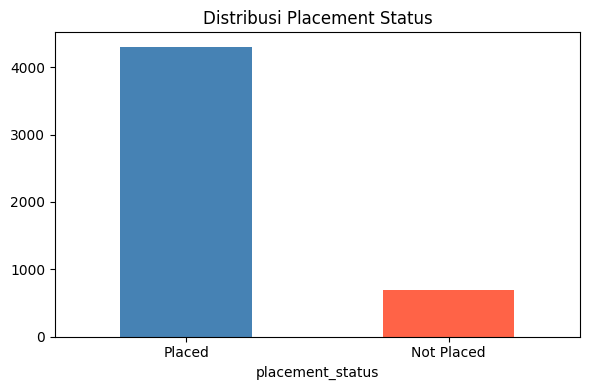

placement_status
Placed        4303
Not Placed     697
Name: count, dtype: int64
Rasio: {'Placed': 86.1, 'Not Placed': 13.9}


In [10]:
# Distribusi target
plt.figure(figsize=(6, 4))
df['placement_status'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Distribusi Placement Status')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(df['placement_status'].value_counts())
print('Rasio:', (df['placement_status'].value_counts(normalize=True) * 100).round(1).to_dict())

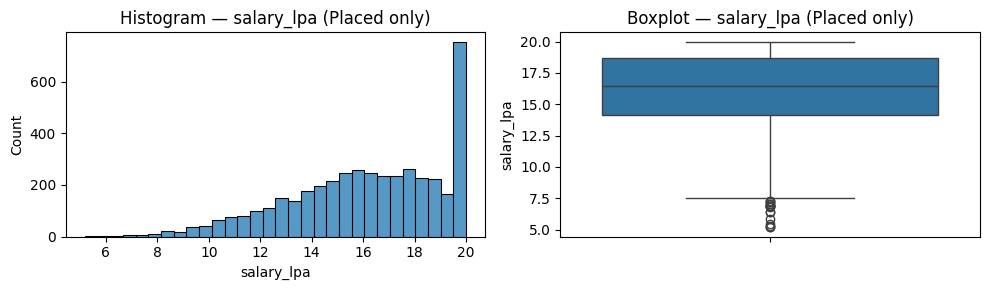

Skewness: -0.5807  |  Kurtosis: -0.2685


In [11]:
# Distribusi salary (hanya Placed — salary=0 untuk Not Placed tidak relevan)
placed_salary = df[df['placement_status'] == 'Placed']['salary_lpa']

plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
sns.histplot(placed_salary, bins=30)
plt.title('Histogram — salary_lpa (Placed only)')

plt.subplot(1, 2, 2)
sns.boxplot(y=placed_salary)
plt.title('Boxplot — salary_lpa (Placed only)')

plt.tight_layout()
plt.show()
print(f'Skewness: {placed_salary.skew():.4f}  |  Kurtosis: {placed_salary.kurt():.4f}')

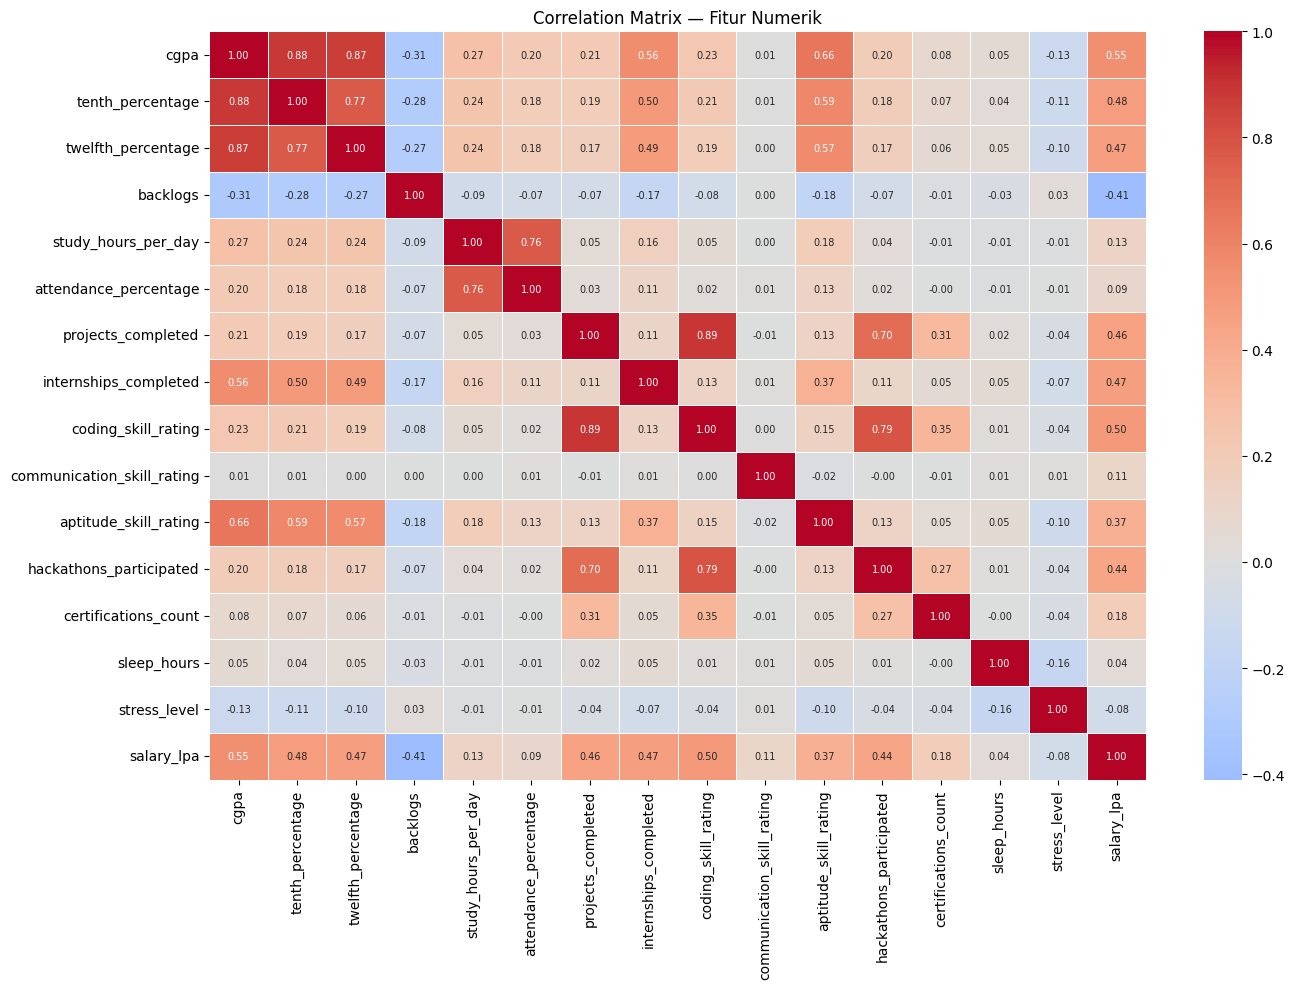

In [12]:
# Correlation heatmap
plt.figure(figsize=(14, 10))
corr_matrix = df[num_cols + ['salary_lpa']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 7})
plt.title('Correlation Matrix — Fitur Numerik')
plt.tight_layout()
plt.show()

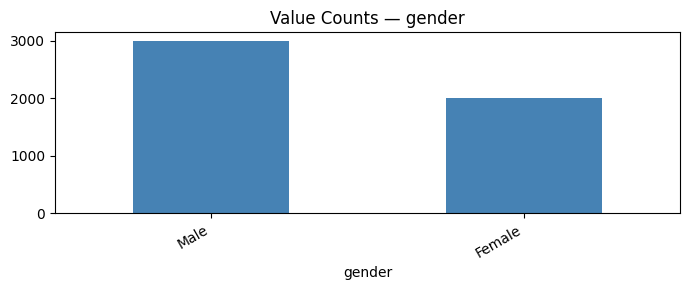

gender
Male      2999
Female    2001
Name: count, dtype: int64 



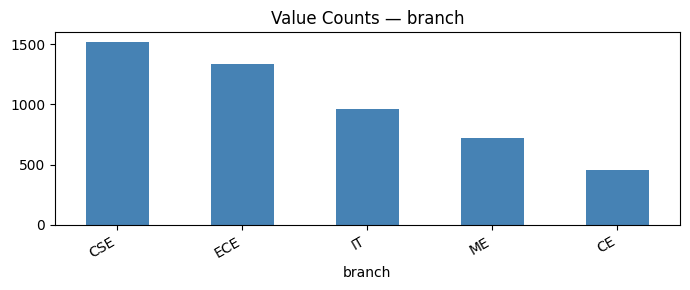

branch
CSE    1522
ECE    1336
IT      963
ME      725
CE      454
Name: count, dtype: int64 



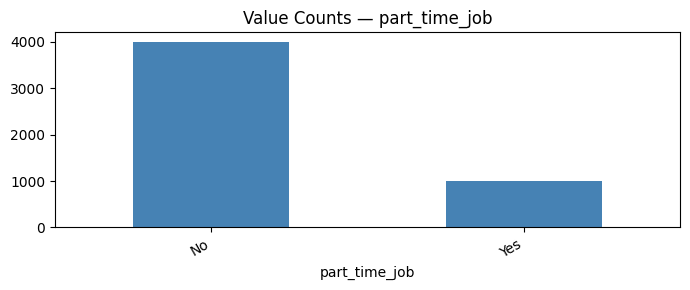

part_time_job
No     4007
Yes     993
Name: count, dtype: int64 



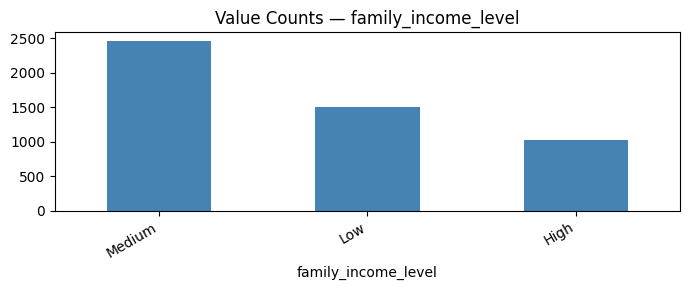

family_income_level
Medium    2466
Low       1503
High      1031
Name: count, dtype: int64 



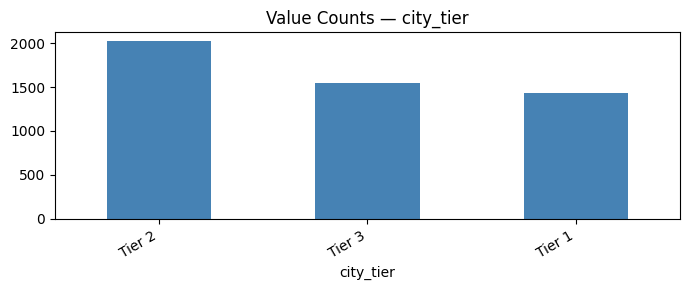

city_tier
Tier 2    2023
Tier 3    1547
Tier 1    1430
Name: count, dtype: int64 



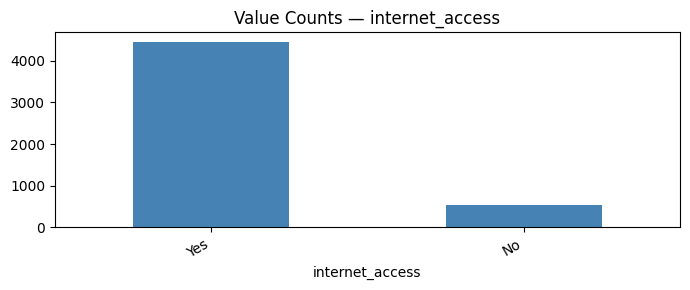

internet_access
Yes    4461
No      539
Name: count, dtype: int64 



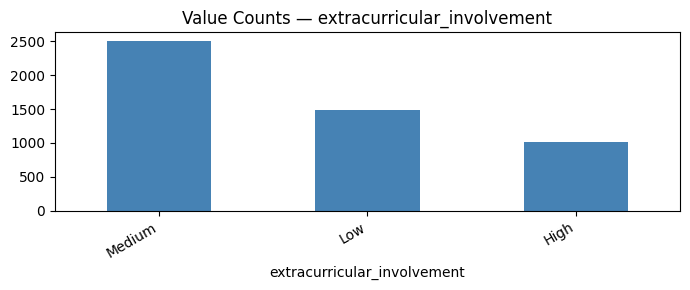

extracurricular_involvement
Medium    2507
Low       1485
High      1008
Name: count, dtype: int64 



In [13]:
# Distribusi fitur kategorik
for col in cat_cols:
    plt.figure(figsize=(7, 3))
    df[col].value_counts().plot(kind='bar', color='steelblue')
    plt.title(f'Value Counts — {col}')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()
    print(df[col].value_counts(), '\n')

### Encoding Kategorik

In [14]:
for col in cat_cols:
    print(f'{col}: {sorted(df[col].dropna().unique().tolist())}')

gender: ['Female', 'Male']
branch: ['CE', 'CSE', 'ECE', 'IT', 'ME']
part_time_job: ['No', 'Yes']
family_income_level: ['High', 'Low', 'Medium']
city_tier: ['Tier 1', 'Tier 2', 'Tier 3']
internet_access: ['No', 'Yes']
extracurricular_involvement: ['High', 'Low', 'Medium']


In [15]:
# LabelEncoder
binary_cols = ['gender', 'part_time_job', 'internet_access']

# OrdinalEncoder
ordinal_config = {
    'family_income_level'        : ['Low', 'Medium', 'High'],
    'city_tier'                  : ['Tier 3', 'Tier 2', 'Tier 1'],
    'extracurricular_involvement': ['None', 'Low', 'Medium', 'High'],
}

# OneHotEncoder
nominal_cols = ['branch']

# fit encoder
bin_enc_dict = {col: LabelEncoder() for col in binary_cols}
ord_enc_dict = {
    col: OrdinalEncoder(categories=[cats], handle_unknown='use_encoded_value', unknown_value=-1)
    for col, cats in ordinal_config.items()
}
ohe_enc = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

data = df.copy().reset_index(drop=True)

for col in binary_cols:
    data[col] = bin_enc_dict[col].fit_transform(data[col].astype(str))

for col, enc in ord_enc_dict.items():
    data[col] = enc.fit_transform(data[[col]])

oh_encoded = ohe_enc.fit_transform(data[nominal_cols])
one_hot_df = pd.DataFrame(oh_encoded, columns=ohe_enc.get_feature_names_out(nominal_cols))
data = pd.concat([data.drop(columns=nominal_cols), one_hot_df.astype('int')], axis=1)

feature_cols = [c for c in data.columns if c not in ['placement_status', 'salary_lpa']]

print('Shape setelah encoding:', data.shape)
data.head()

Shape setelah encoding: (5000, 28)


,gender,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,internships_completed,coding_skill_rating,...,city_tier,internet_access,extracurricular_involvement,placement_status,salary_lpa,branch_CE,branch_CSE,branch_ECE,branch_IT,branch_ME
0,1,8.74,74.0,75.0,0,3.8,71.1,7,3,4,...,1.0,1,2.0,Placed,14.95,0,0,1,0,0
1,0,7.80,75.3,69.7,0,6.3,69.5,5,1,3,...,0.0,1,1.0,Placed,14.91,0,0,1,0,0
2,0,6.95,62.8,68.3,0,1.5,62.5,8,2,5,...,1.0,1,3.0,Placed,17.73,0,0,0,1,0
3,1,7.46,57.9,51.4,1,4.7,64.6,6,2,3,...,2.0,1,1.0,Placed,14.52,0,0,1,0,0
4,1,6.86,61.3,73.5,2,5.2,75.9,3,3,2,...,2.0,1,2.0,Placed,15.91,0,0,0,1,0


## CLASSIFICATION (placement_status)

### SPLIT

In [16]:
# Encode target: Placed=1, Not Placed=0
data['placement_enc'] = (data['placement_status'] == 'Placed').astype(int)

X_clf = data[feature_cols]
y_clf = data['placement_enc']

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=SEED, stratify=y_clf
)
print('Train:', X_train_clf.shape, '| Test:', X_test_clf.shape)
print(y_train_clf.value_counts())

Train: (4000, 26) | Test: (1000, 26)
placement_enc
1    3442
0     558
Name: count, dtype: int64


In [17]:
cw_arr = compute_class_weight('balanced', classes=np.unique(y_train_clf), y=y_train_clf)
cw_dict = dict(enumerate(cw_arr))
print('Class weights:', cw_dict)

Class weights: {0: np.float64(3.5842293906810037), 1: np.float64(0.5810575246949448)}


In [18]:
# Scaling
num_feat = [c for c in num_cols if c in feature_cols]

rob_scaler_clf = RobustScaler()
X_train_clf = X_train_clf.copy()
X_test_clf  = X_test_clf.copy()

X_train_clf[num_feat] = rob_scaler_clf.fit_transform(X_train_clf[num_feat])
X_test_clf[num_feat]  = rob_scaler_clf.transform(X_test_clf[num_feat])

In [19]:
def calc_class_metrics(model_name, y_true, y_preds, y_preds_proba=None):
    res_dict = {
        'Model'    : model_name,
        'Accuracy' : accuracy_score(y_true, y_preds),
        'Recall'   : recall_score(y_true, y_preds, zero_division=0),
        'Precision': precision_score(y_true, y_preds, zero_division=0),
        'F1_Score' : f1_score(y_true, y_preds, zero_division=0),
    }
    if y_preds_proba is not None:
        res_dict['AUC'] = roc_auc_score(y_true, y_preds_proba)
    return res_dict

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Not Placed', 'Placed'])
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix — {title}')
    plt.show()

clf_results = []

### Model 1 — Logistic Regression

Baseline yang cepat dan interpretable untuk klasifikasi biner. class_weight digunakan untuk handle imbalanced tanpa perlu resampling.

              precision    recall  f1-score   support

  Not Placed       0.44      0.81      0.57       139
      Placed       0.96      0.83      0.89       861

    accuracy                           0.83      1000
   macro avg       0.70      0.82      0.73      1000
weighted avg       0.89      0.83      0.85      1000



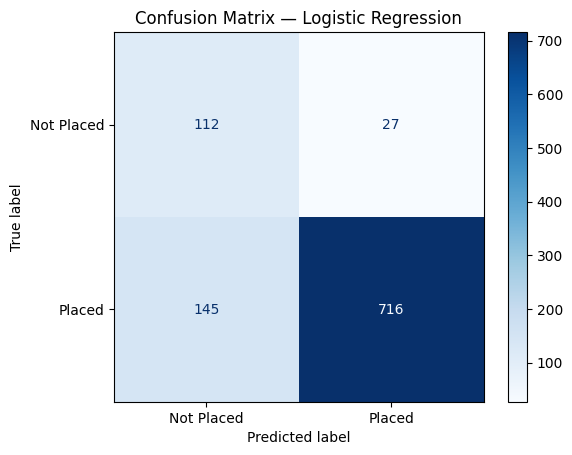

In [20]:
lr_clf = LogisticRegression(class_weight=cw_dict, max_iter=1000, random_state=SEED)
lr_clf.fit(X_train_clf, y_train_clf)

y_pred_lr  = lr_clf.predict(X_test_clf)
y_proba_lr = lr_clf.predict_proba(X_test_clf)[:, 1]

print(classification_report(y_test_clf, y_pred_lr, target_names=['Not Placed', 'Placed']))
plot_cm(y_test_clf, y_pred_lr, 'Logistic Regression')

clf_results.append(calc_class_metrics('Logistic Regression', y_test_clf, y_pred_lr, y_proba_lr))

### Model 2 — Decision Tree

Menangkap hubungan non-linear. max_depth=7 untuk mencegah overfitting.

              precision    recall  f1-score   support

  Not Placed       0.34      0.73      0.47       139
      Placed       0.95      0.78      0.85       861

    accuracy                           0.77      1000
   macro avg       0.64      0.75      0.66      1000
weighted avg       0.86      0.77      0.80      1000



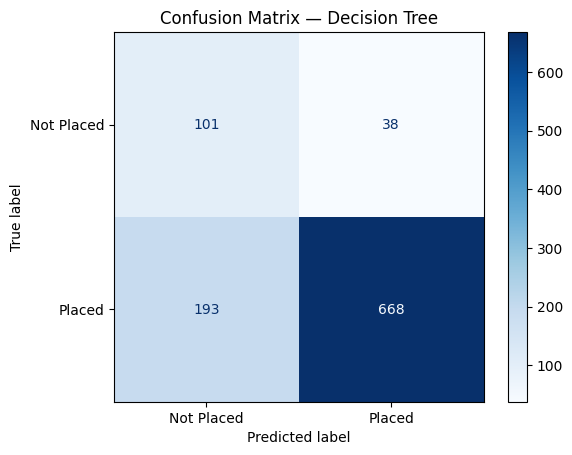

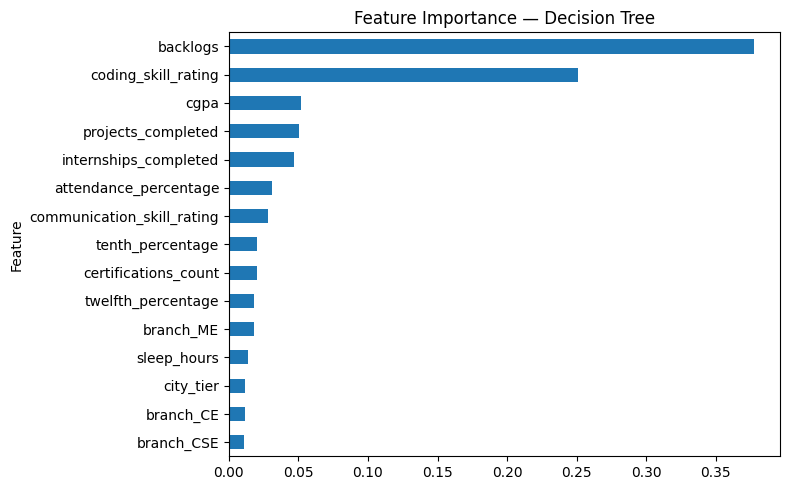

In [21]:
dt_clf = DecisionTreeClassifier(criterion='gini', max_depth=7,
                                 class_weight=cw_dict, random_state=SEED)
dt_clf.fit(X_train_clf, y_train_clf)

y_pred_dt  = dt_clf.predict(X_test_clf)
y_proba_dt = dt_clf.predict_proba(X_test_clf)[:, 1]

print(classification_report(y_test_clf, y_pred_dt, target_names=['Not Placed', 'Placed']))
plot_cm(y_test_clf, y_pred_dt, 'Decision Tree')

feat_imp = pd.DataFrame({'Feature': X_train_clf.columns,
                         'Importance': dt_clf.feature_importances_})
feat_imp.sort_values('Importance', ascending=True).tail(15).plot(
    kind='barh', x='Feature', y='Importance', figsize=(8, 5),
    title='Feature Importance — Decision Tree', legend=False
)
plt.tight_layout()
plt.show()

clf_results.append(calc_class_metrics('Decision Tree', y_test_clf, y_pred_dt, y_proba_dt))

### Model 3 — Random Forest

Gabungan dari banyak Decision Tree: lebih robust terhadap overfitting dan noise, umumnya performa terbaik untuk tabular data.

              precision    recall  f1-score   support

  Not Placed       0.57      0.54      0.55       139
      Placed       0.93      0.93      0.93       861

    accuracy                           0.88      1000
   macro avg       0.75      0.74      0.74      1000
weighted avg       0.88      0.88      0.88      1000



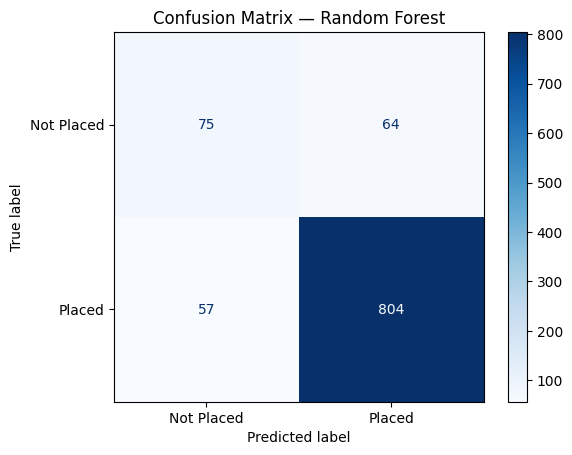

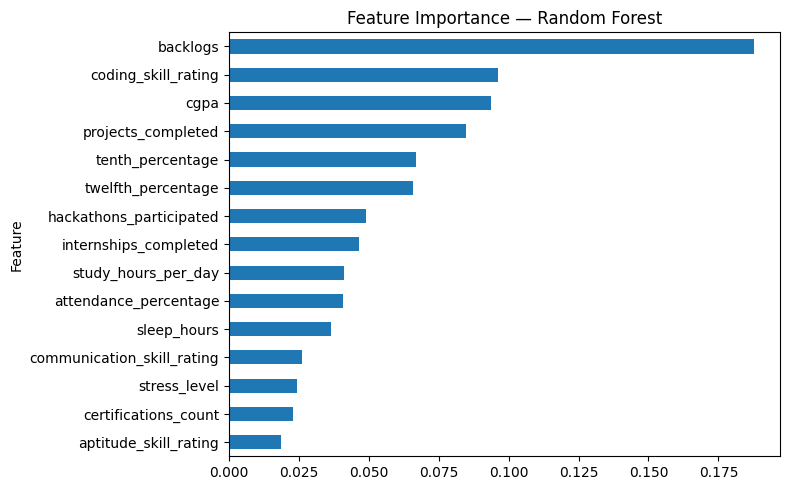

In [22]:
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=10,
                                 class_weight=cw_dict, random_state=SEED, n_jobs=-1)
rf_clf.fit(X_train_clf, y_train_clf)

y_pred_rf  = rf_clf.predict(X_test_clf)
y_proba_rf = rf_clf.predict_proba(X_test_clf)[:, 1]

print(classification_report(y_test_clf, y_pred_rf, target_names=['Not Placed', 'Placed']))
plot_cm(y_test_clf, y_pred_rf, 'Random Forest')

feat_imp_rf = pd.DataFrame({'Feature': X_train_clf.columns,
                             'Importance': rf_clf.feature_importances_})
feat_imp_rf.sort_values('Importance', ascending=True).tail(15).plot(
    kind='barh', x='Feature', y='Importance', figsize=(8, 5),
    title='Feature Importance — Random Forest', legend=False
)
plt.tight_layout()
plt.show()

clf_results.append(calc_class_metrics('Random Forest', y_test_clf, y_pred_rf, y_proba_rf))

### CLASSIFICATION: EVALUATION

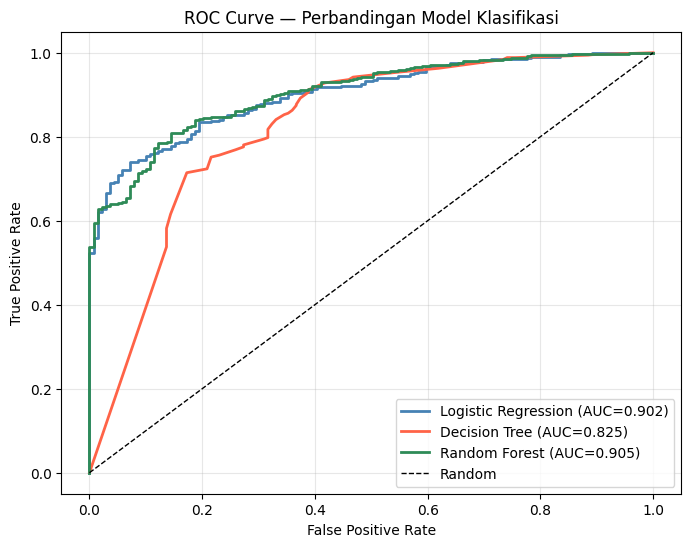

In [23]:
plt.figure(figsize=(8, 6))
for name, proba, color in [
    ('Logistic Regression', y_proba_lr, 'steelblue'),
    ('Decision Tree',       y_proba_dt, 'tomato'),
    ('Random Forest',       y_proba_rf, 'seagreen'),
]:
    fpr, tpr, _ = roc_curve(y_test_clf, proba)
    auc = roc_auc_score(y_test_clf, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, linewidth=2)

plt.plot([0,1],[0,1],'k--', linewidth=1, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Perbandingan Model Klasifikasi')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

In [24]:
clf_summary = pd.DataFrame(clf_results).set_index('Model')
print('=== Perbandingan Model Klasifikasi ===')
print(clf_summary.round(4).to_string())

best_clf_name = clf_summary['F1_Score'].idxmax()
print(f'\nModel terbaik (F1): {best_clf_name} — {clf_summary.loc[best_clf_name,"F1_Score"]:.4f}')

=== Perbandingan Model Klasifikasi ===
                     Accuracy  Recall  Precision  F1_Score     AUC
Model                                                             
Logistic Regression     0.828  0.8316     0.9637    0.8928  0.9023
Decision Tree           0.769  0.7758     0.9462    0.8526  0.8252
Random Forest           0.879  0.9338     0.9263    0.9300  0.9047

Model terbaik (F1): Random Forest — 0.9300


dari kurva ROC dan hasil perbandingan ini, model Random Forest menunjukkan performa klasifikasi paling bagus dengan AUC sebesar 0.905. Tapi logistic regression juga hampir mendekati RF dengan AUC = 0.902, sehingga kedua model tersebut terbukti sangat baik dalam membedakan kelas target. Sebaliknya, Decision Tree memiliki performa yang tertinggal dengan AUC terendah (0.825). Kesimpulannya, Random Forest atau Logistic Regression adalah kandidat model yang paling ideal untuk dilanjutkan ke tahap evaluasi berikutnya.

### HyperOpt — Random Forest

Untuk naikin performa model RF

In [25]:
def fit_clf_model(params):
    model = RandomForestClassifier(
        n_estimators     = int(params['n_estimators']),
        max_depth        = int(params['max_depth']),
        min_samples_leaf = int(params['min_samples_leaf']),
        criterion        = params['criterion'],
        class_weight     = cw_dict,
        random_state     = SEED, n_jobs=-1
    )
    model.fit(X_train_clf, y_train_clf)
    y_pred = model.predict(X_test_clf)
    return {'loss': 1 - recall_score(y_test_clf, y_pred, zero_division=0),
            'status': STATUS_OK}

clf_space = {
    'n_estimators'    : hp.choice('n_estimators',    [50, 100, 200]),
    'max_depth'       : hp.choice('max_depth',        [5, 10, 15, 20]),
    'min_samples_leaf': hp.choice('min_samples_leaf', [1, 3, 5]),
    'criterion'       : hp.choice('criterion',        ['gini', 'entropy']),
}

trials_clf  = Trials()
best_clf_idx = fmin(
    fit_clf_model, space=clf_space, algo=tpe.suggest,
    max_evals=30, trials=trials_clf, rstate=np.random.default_rng(SEED)
)
print('Best params index:', best_clf_idx)

100%|██████████| 30/30 [00:09<00:00,  3.14trial/s, best loss: 0.016260162601625994]
Best params index: {'criterion': np.int64(1), 'max_depth': np.int64(3), 'min_samples_leaf': np.int64(0), 'n_estimators': np.int64(2)}


              precision    recall  f1-score   support

  Not Placed       0.75      0.30      0.43       139
      Placed       0.90      0.98      0.94       861

    accuracy                           0.89      1000
   macro avg       0.82      0.64      0.68      1000
weighted avg       0.88      0.89      0.87      1000



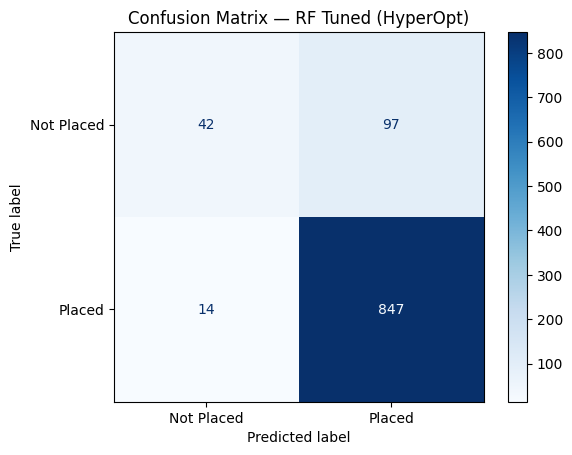

=== Final Comparison Klasifikasi ===
                     Accuracy  Recall  Precision  F1_Score     AUC
Model                                                             
Logistic Regression     0.828  0.8316     0.9637    0.8928  0.9023
Decision Tree           0.769  0.7758     0.9462    0.8526  0.8252
Random Forest           0.879  0.9338     0.9263    0.9300  0.9047
RF Tuned                0.889  0.9837     0.8972    0.9385  0.9063


In [26]:
n_est_opts = [50, 100, 200]
depth_opts = [5, 10, 15, 20]
leaf_opts  = [1, 3, 5]
crit_opts  = ['gini', 'entropy']

rf_clf_tuned = RandomForestClassifier(
    n_estimators     = n_est_opts[best_clf_idx['n_estimators']],
    max_depth        = depth_opts[best_clf_idx['max_depth']],
    min_samples_leaf = leaf_opts[best_clf_idx['min_samples_leaf']],
    criterion        = crit_opts[best_clf_idx['criterion']],
    class_weight     = cw_dict,
    random_state     = SEED, n_jobs=-1
)
rf_clf_tuned.fit(X_train_clf, y_train_clf)

y_pred_tuned_clf  = rf_clf_tuned.predict(X_test_clf)
y_proba_tuned_clf = rf_clf_tuned.predict_proba(X_test_clf)[:, 1]

print(classification_report(y_test_clf, y_pred_tuned_clf, target_names=['Not Placed', 'Placed']))
plot_cm(y_test_clf, y_pred_tuned_clf, 'RF Tuned (HyperOpt)')

clf_results.append(calc_class_metrics('RF Tuned', y_test_clf, y_pred_tuned_clf, y_proba_tuned_clf))

print('=== Final Comparison Klasifikasi ===')
print(pd.DataFrame(clf_results).set_index('Model').round(4).to_string())

metrik Accuracy (proporsi tebakan yang benar secara keseluruhan) sering kali kurang informatif, terutama jika dihadapkan pada dataset yang imbalanced. Oleh karena itu, penentuan model terbaik harus didasarkan pada metrik yang lebih komprehensif. Pada kasus ini, prioritas utama dievaluasi menggunakan Recall, yakni seberapa besar persentase kandidat yang benar-benar Placed berhasil dideteksi oleh model. Model Random Forest yang telah di-tune (RF Tuned) keluar sebagai model paling superior dengan nilai Recall tertinggi mencapai 0.9837 (98,37%). Ini berarti model tersebut nyaris tidak melewatkan satu pun kandidat potensial.

Tingginya sensitivitas RF Tuned memang sedikit mengorbankan Precision, persentase kebenaran dari semua tebakan Placed yang dihasilkan model—yang turun menjadi 0.8972, sedikit di bawah Logistic Regression (0.9637). Meski demikian, kompromi ini terbukti sangat sepadan jika melihat F1-Score (rata-rata harmonik dari Precision dan Recall) yang merupakan metrik utama untuk menangani imbalanced data. RF Tuned kembali memimpin dengan F1-Score sebesar 0.9385. Terakhir, performa ini divalidasi dengan sangat meyakinkan oleh metrik AUC-ROC yang mengukur seberapa baik model mampu memisahkan antara kedua kelas (Placed vs Not Placed). Secara umum, seluruh model menunjukkan kemampuan pemisahan yang baik (>0.8), namun RF Tuned tetap menjadi yang terbaik dengan skor AUC tertinggi (0.9063), menjadikannya model final yang paling optimal untuk digunakan.

---
# REGRESSION (salary_lpa)

regresi hanya dilakukan pada data 'Placed' sebagai orang yang keterima kerja.

In [27]:
data_placed = data[data['placement_status'] == 'Placed'].copy().reset_index(drop=True)
print(f'Data Placed: {len(data_placed)} baris')

X_reg = data_placed[feature_cols]
y_reg = data_placed['salary_lpa']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=SEED
)
print('Train:', X_train_reg.shape, '| Test:', X_test_reg.shape)

Data Placed: 4303 baris
Train: (3442, 26) | Test: (861, 26)


In [28]:
X_train_reg = X_train_reg.copy()
X_test_reg  = X_test_reg.copy()

rob_scaler_reg = RobustScaler()
X_train_reg[num_feat] = rob_scaler_reg.fit_transform(X_train_reg[num_feat])
X_test_reg[num_feat]  = rob_scaler_reg.transform(X_test_reg[num_feat])

y_scaler_reg = RobustScaler()
y_train_reg_sc = y_scaler_reg.fit_transform(pd.DataFrame(y_train_reg))
y_test_reg_sc  = y_scaler_reg.transform(pd.DataFrame(y_test_reg))

### Helper Functions untuk Regression

In [29]:
def evaluate_regression(model_name, y_true, y_pred):
    return {
        'Model': model_name,
        'MAE'  : mae(y_true, y_pred),
        'MSE'  : mse(y_true, y_pred),
        'RMSE' : np.sqrt(mse(y_true, y_pred)),
        'R2'   : r2(y_true, y_pred),
    }

def plot_actual_vs_predicted(y_true, y_pred, title=''):
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.4, color='steelblue')
    mn = min(y_true.min(), y_pred.min())
    mx = max(y_true.max(), y_pred.max())
    plt.axline((mn, mn), slope=1, linestyle='--', color='red', linewidth=1.5)
    plt.xlabel('Actual Salary (LPA)')
    plt.ylabel('Predicted Salary (LPA)')
    plt.title(f'Actual vs Predicted — {title}')
    plt.tight_layout()
    plt.show()

reg_results = []

### Model 1 — Linear Regression

model klasik, pembanding utama, koefisiennya langsung menunjukkan kontribusi tiap fitur terhadap salary.

{'Model': 'Linear Regression', 'MAE': 1.0900838268991706, 'MSE': 1.917881160668318, 'RMSE': np.float64(1.3848758647143498), 'R2': 0.7735767090805402}


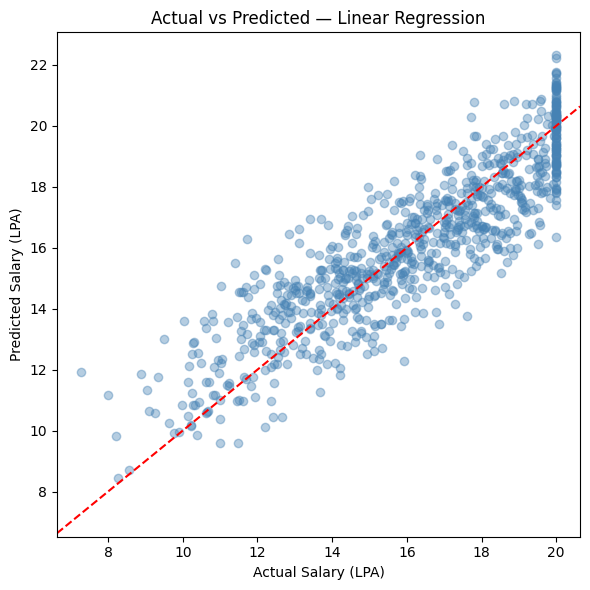

In [30]:
lr_reg = LinearRegression()
lr_reg.fit(X_train_reg, y_train_reg_sc)

y_pred_lr_sc  = lr_reg.predict(X_test_reg)
y_test_inv    = y_scaler_reg.inverse_transform(y_test_reg_sc)
y_pred_lr_inv = y_scaler_reg.inverse_transform(y_pred_lr_sc.reshape(-1, 1))

res_lr_reg = evaluate_regression('Linear Regression', y_test_inv, y_pred_lr_inv)
print(res_lr_reg)
reg_results.append(res_lr_reg)
plot_actual_vs_predicted(y_test_inv, y_pred_lr_inv, 'Linear Regression')

### Model 2 — Ridge Regression

Regularisasi L2 membuat model lebih stabil saat ada korelasi antar fitur (terlihat dari heatmap).

{'Model': 'Ridge Regression', 'MAE': 1.0900753320957262, 'MSE': 1.9178873379835166, 'RMSE': np.float64(1.3848780949901391), 'R2': 0.7735759797923731}


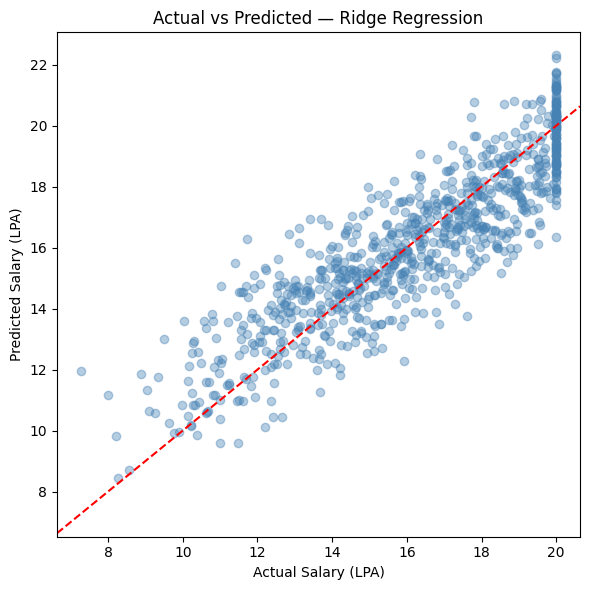

In [31]:
ridge_reg = Ridge(alpha=1.0)
ridge_reg.fit(X_train_reg, y_train_reg_sc)

y_pred_ridge_sc  = ridge_reg.predict(X_test_reg)
y_pred_ridge_inv = y_scaler_reg.inverse_transform(y_pred_ridge_sc.reshape(-1, 1))

res_ridge = evaluate_regression('Ridge Regression', y_test_inv, y_pred_ridge_inv)
print(res_ridge)
reg_results.append(res_ridge)
plot_actual_vs_predicted(y_test_inv, y_pred_ridge_inv, 'Ridge Regression')

### Model 3 — Decision Tree Regressor

bisa menangkap hubungan non-linear yang tidak bisa ditangkap model linear.

{'Model': 'Decision Tree Regressor', 'MAE': 1.3670026097440233, 'MSE': 3.1406440270504548, 'RMSE': np.float64(1.7721862280952458), 'R2': 0.6292184464841875}


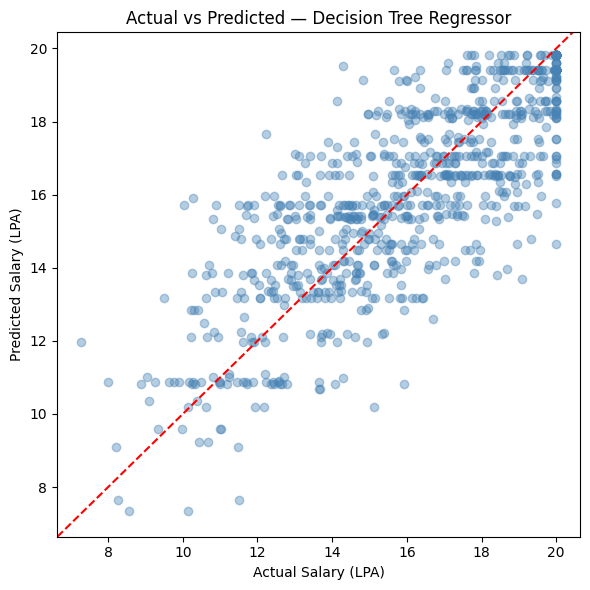

In [32]:
dt_reg = DecisionTreeRegressor(max_depth=7, random_state=SEED)
dt_reg.fit(X_train_reg, y_train_reg_sc.ravel())

y_pred_dt_sc  = dt_reg.predict(X_test_reg)
y_pred_dt_inv = y_scaler_reg.inverse_transform(y_pred_dt_sc.reshape(-1, 1))

res_dt_reg = evaluate_regression('Decision Tree Regressor', y_test_inv, y_pred_dt_inv)
print(res_dt_reg)
reg_results.append(res_dt_reg)
plot_actual_vs_predicted(y_test_inv, y_pred_dt_inv, 'Decision Tree Regressor')

## 17. Model 4 — Random Forest Regressor + HyperOpt

**Alasan:** Ensemble RF lebih robust dari single DT. HyperOpt mencari hyperparameter optimal dengan efisien. **Metrik: MSE** (minimasi error kuadrat).

{'Model': 'RF Regressor', 'MAE': 1.1848470684055954, 'MSE': 2.3026753883806204, 'RMSE': np.float64(1.517456881885156), 'R2': 0.7281482554556707}


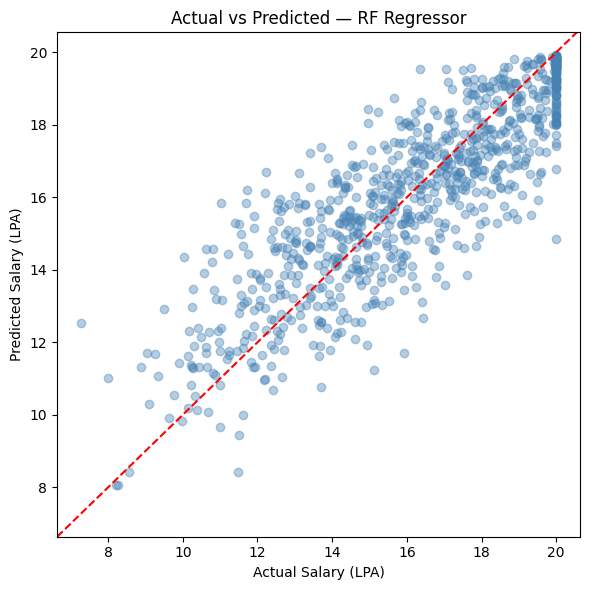

In [33]:
# Baseline RF Regressor
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=SEED, n_jobs=-1)
rf_reg.fit(X_train_reg, y_train_reg_sc.ravel())

y_pred_rf_sc  = rf_reg.predict(X_test_reg)
y_pred_rf_inv = y_scaler_reg.inverse_transform(y_pred_rf_sc.reshape(-1, 1))

res_rf_reg = evaluate_regression('RF Regressor', y_test_inv, y_pred_rf_inv)
print(res_rf_reg)
reg_results.append(res_rf_reg)
plot_actual_vs_predicted(y_test_inv, y_pred_rf_inv, 'RF Regressor')

In [34]:
def fit_reg_model(params):
    model = RandomForestRegressor(
        n_estimators     = int(params['n_estimators']),
        max_depth        = params['max_depth'],
        min_samples_leaf = int(params['min_samples_leaf']),
        random_state     = SEED, n_jobs=-1
    )
    model.fit(X_train_reg, y_train_reg_sc.ravel())
    y_pred = model.predict(X_test_reg)
    return {'loss': mse(y_test_reg_sc, y_pred), 'status': STATUS_OK}

reg_space = {
    'n_estimators'    : hp.choice('n_estimators',    [50, 100, 200]),
    'max_depth'       : hp.choice('max_depth',        [5, 10, 15, None]),
    'min_samples_leaf': hp.choice('min_samples_leaf', [1, 3, 5]),
}

trials_reg   = Trials()
best_reg_idx = fmin(
    fit_reg_model, space=reg_space, algo=tpe.suggest,
    max_evals=30, trials=trials_reg, rstate=np.random.default_rng(SEED)
)
print('Best params index:', best_reg_idx)

100%|██████████| 30/30 [00:08<00:00,  3.47trial/s, best loss: 0.11511502725365617]
Best params index: {'max_depth': np.int64(1), 'min_samples_leaf': np.int64(0), 'n_estimators': np.int64(1)}


{'Model': 'RF Tuned (HyperOpt)', 'MAE': 1.1848470684055952, 'MSE': 2.302675388380621, 'RMSE': np.float64(1.5174568818851562), 'R2': 0.7281482554556707}


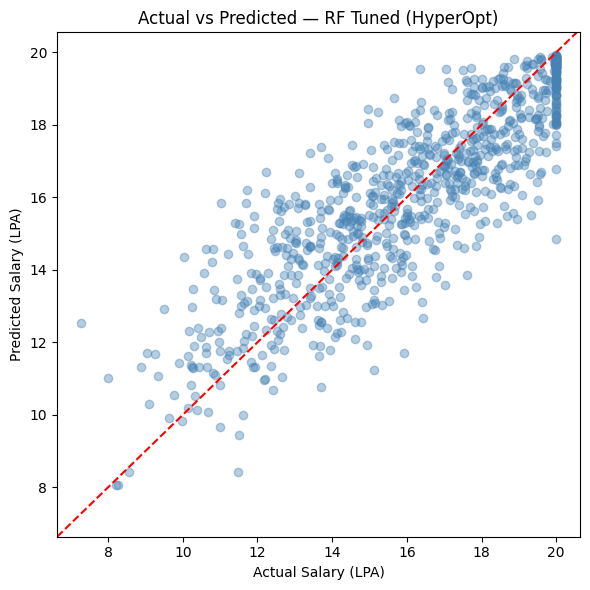

In [35]:
n_est_opts = [50, 100, 200]
depth_opts = [5, 10, 15, None]
leaf_opts  = [1, 3, 5]

rf_reg_tuned = RandomForestRegressor(
    n_estimators     = n_est_opts[best_reg_idx['n_estimators']],
    max_depth        = depth_opts[best_reg_idx['max_depth']],
    min_samples_leaf = leaf_opts[best_reg_idx['min_samples_leaf']],
    random_state     = SEED, n_jobs=-1
)
rf_reg_tuned.fit(X_train_reg, y_train_reg_sc.ravel())

y_pred_tuned_sc  = rf_reg_tuned.predict(X_test_reg)
y_pred_tuned_inv = y_scaler_reg.inverse_transform(y_pred_tuned_sc.reshape(-1, 1))

res_rf_tuned = evaluate_regression('RF Tuned (HyperOpt)', y_test_inv, y_pred_tuned_inv)
print(res_rf_tuned)
reg_results.append(res_rf_tuned)
plot_actual_vs_predicted(y_test_inv, y_pred_tuned_inv, 'RF Tuned (HyperOpt)')

### EVALUATION: REGRESSION

In [36]:
reg_summary = pd.DataFrame(reg_results).set_index('Model')
print('=== Perbandingan Model Regresi ===')
print(reg_summary.round(4).to_string())

best_reg_name = reg_summary['R2'].idxmax()
print(f'\nModel terbaik (R2): {best_reg_name} — {reg_summary.loc[best_reg_name,"R2"]:.4f}')

=== Perbandingan Model Regresi ===
                            MAE     MSE    RMSE      R2
Model                                                  
Linear Regression        1.0901  1.9179  1.3849  0.7736
Ridge Regression         1.0901  1.9179  1.3849  0.7736
Decision Tree Regressor  1.3670  3.1406  1.7722  0.6292
RF Regressor             1.1848  2.3027  1.5175  0.7281
RF Tuned (HyperOpt)      1.1848  2.3027  1.5175  0.7281

Model terbaik (R2): Linear Regression — 0.7736


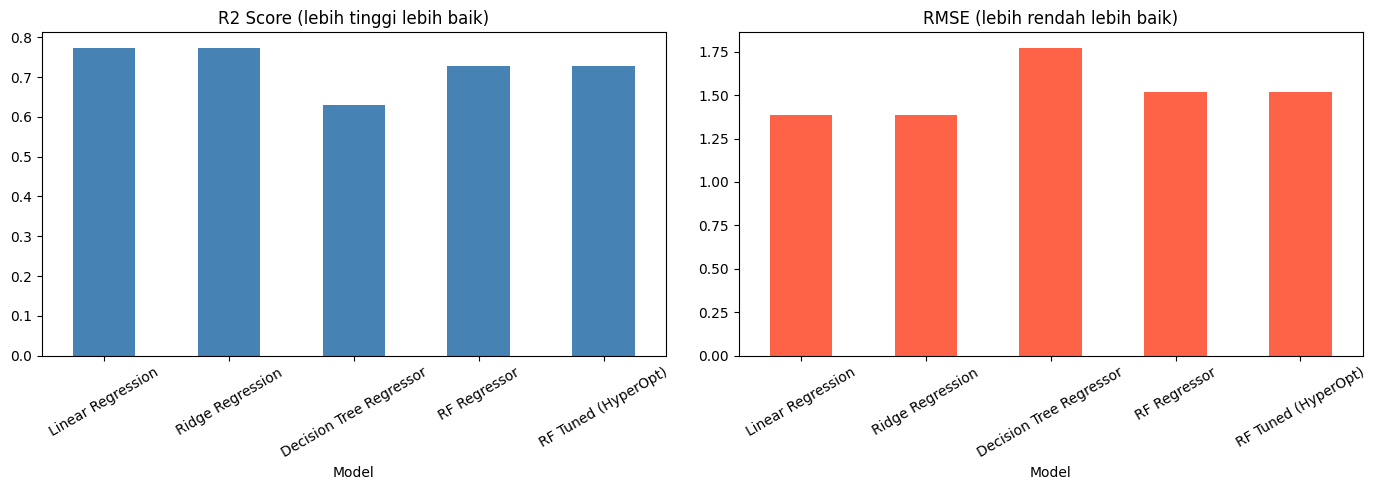

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
reg_summary['R2'].plot(kind='bar', ax=axes[0], color='steelblue',
                       title='R2 Score (lebih tinggi lebih baik)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='center')

reg_summary['RMSE'].plot(kind='bar', ax=axes[1], color='tomato',
                         title='RMSE (lebih rendah lebih baik)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='center')

plt.tight_layout()
plt.show()

dimana
- **MAE:** Rata-rata error prediksi dalam satuan LPA. Paling mudah diinterpretasi.
- **RMSE:** Lebih sensitif terhadap error besar. Jika RMSE jauh lebih besar dari MAE, berarti ada prediksi yang meleset jauh.
- **R²:** Proporsi variansi salary yang bisa dijelaskan model. R²=1 sempurna, R²=0 tidak lebih baik dari mean.

### Save Model & Artifacts

In [38]:
exp_path = 'exp/placement/'
os.makedirs(exp_path, exist_ok=True)

artifacts = {
    'clf_model'      : rf_clf_tuned,
    'reg_model'      : rf_reg_tuned,
    'rob_scaler_clf' : rob_scaler_clf,
    'rob_scaler_reg' : rob_scaler_reg,
    'y_scaler_reg'   : y_scaler_reg,
    'bin_enc_dict'   : bin_enc_dict,
    'ord_enc_dict'   : ord_enc_dict,
    'ohe_enc'        : ohe_enc,
    'feature_cols'   : feature_cols,
    'num_feat'       : num_feat,
}

for name, obj in artifacts.items():
    with open(os.path.join(exp_path, f'{name}.pkl'), 'wb') as f:
        pickle.dump(obj, f)

print(f'Semua artifacts tersimpan di {exp_path}')
print(list(artifacts.keys()))

Semua artifacts tersimpan di exp/placement/
['clf_model', 'reg_model', 'rob_scaler_clf', 'rob_scaler_reg', 'y_scaler_reg', 'bin_enc_dict', 'ord_enc_dict', 'ohe_enc', 'feature_cols', 'num_feat']


Kesimpulan akhir dari project ini, yang pertama, pada tugas klasifikasi, algoritma Logistic Regression dan Decision Tree unggul dalam kemudahan interpretasi, namun keduanya memiliki keterbatasan terkait asumsi korelasi linear dan kerentanan terhadap overfitting. Penggunaan Random Forest terbukti mampu mengatasi masalah tersebut dengan memberikan tingkat akurasi dan ketahanan (robustness) yang jauh lebih tinggi. jadi dapat disimpulkan Random Forest yang dioptimasi secara spesifik menggunakan HyperOpt adalah yang paling optimal.

Pola yg sama juga ada pada pemodelan regresi. Pendekatan baseline seperti Linear Regression dan Ridge Regression sangat transparan dalam membaca koefisien dan cukup stabil saat menghadapi multikolinearitas, namun kinerjanya terbatas karena hanya mampu membaca pola garis lurus. Meskipun Decision Tree Regressor mampu menangkap pola non-linear dari data, model ini berisiko tinggi mengalami overfit jika tanpa batasan kedalaman. Sebagai solusinya RF Regressor dengan HyperOpt terpilih jadi model dengan R-Squared tertinggi dan RMSE terendah, menjadikannya model regresi yang paling oke terlepas beban komputasinya berat.

Berdasarkan analisis feature importance dari model ini, masa depan karir dan ekspektasi gaji seorang kandidat sangat ditentukan oleh lima fitur utama, yakni: pencapaian akademik secara keseluruhan (cgpa), penilaian keterampilan teknis dan penalaran logis (coding_skill_rating dan aptitude_skill_rating), tingkat kedisiplinan (attendance_percentage), serta rekam jejak pengalaman kerja dunia nyata melalui magang (internships_completed).

LINK STREAMLIT: https://student-placement-predictor-g3vsdauva7pgqjrwsaxjcx.streamlit.app/

PENJELASAN VIDEO: https://drive.google.com/drive/folders/13MnvHXHgBK5r7qNpMMgqlyDHM3s_FN1w?usp=sharing